In [34]:
!pip install kagglehub

In [35]:
import numpy as np

In [36]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_3cb6e7a408ba1c739edc6612491d0d6a"

In [37]:
import kagglehub

path = kagglehub.dataset_download(
    "andradaolteanu/gtzan-dataset-music-genre-classification"
)

print(path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
/kaggle/input/gtzan-dataset-music-genre-classification


In [38]:
import os

os.listdir(path)

['Data']

In [39]:
os.listdir(
    path + "/Data"
)

['features_3_sec.csv',
 'features_30_sec.csv',
 'images_original',
 'genres_original']

In [40]:
import librosa

audio_path = path + "/Data/genres_original/blues/blues.00000.wav"

y, sr = librosa.load(
    audio_path,
    duration=5
)

print(sr)
print(len(y))

22050
110250


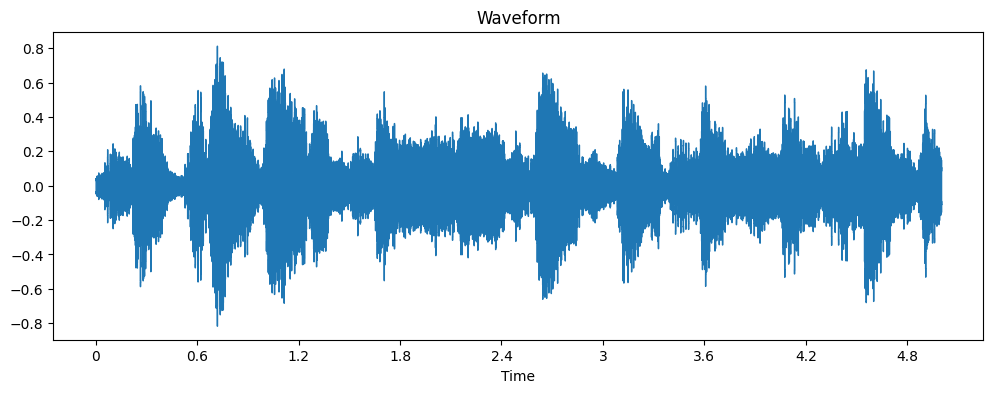

In [41]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title("Waveform")

plt.show()

In [42]:
mfcc = librosa.feature.mfcc(
    y=y,
    sr=sr,
    n_mfcc=13
)

print(mfcc.shape)

(13, 216)


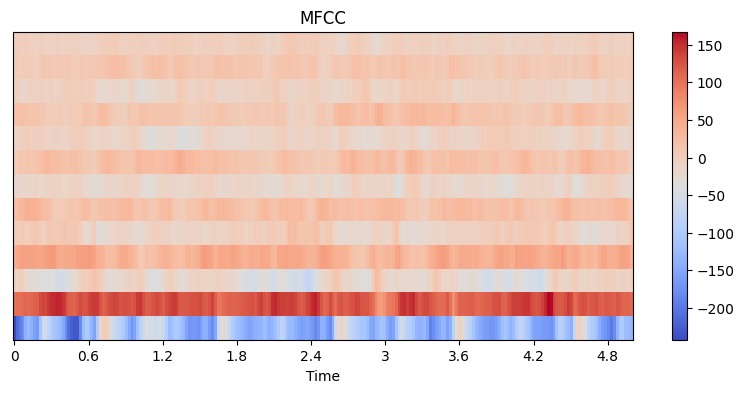

In [43]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC")

plt.show()

In [44]:
from dtaidistance import dtw

In [45]:
audio1, sr = librosa.load(
    path + "/Data/genres_original/blues/blues.00000.wav",
    duration=5
)

audio2, sr = librosa.load(
    path + "/Data/genres_original/blues/blues.00001.wav",
    duration=5
)

mfcc1 = librosa.feature.mfcc(
    y=audio1,
    sr=sr,
    n_mfcc=13
)

mfcc1 = np.mean(mfcc1, axis=1)

mfcc2 = librosa.feature.mfcc(
    y=audio2,
    sr=sr,
    n_mfcc=13
)

mfcc2 = np.mean(mfcc2, axis=1)

distance = dtw.distance(
    mfcc1,
    mfcc2
)

print("DTW Distance :", distance)

DTW Distance : 119.85804592047627


In [46]:
audio3, sr = librosa.load(
    path + "/Data/genres_original/rock/rock.00000.wav",
    duration=5
)

mfcc3 = librosa.feature.mfcc(
    y=audio3,
    sr=sr,
    n_mfcc=13
)

mfcc3 = np.mean(mfcc3, axis=1)

distance2 = dtw.distance(
    mfcc1,
    mfcc3
)

print("Blues vs Rock :", distance2)

Blues vs Rock : 76.85394782882008


In [47]:
database = []

genres = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

for genre in genres:

    for i in range(10):

        filename = f"{genre}.{i:05d}.wav"

        file_path = (
            path
            + "/Data/genres_original/"
            + genre
            + "/"
            + filename
        )

        y, sr = librosa.load(
            file_path,
            duration=5
        )

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=13
        )

        mfcc = np.mean(
            mfcc,
            axis=1
        )

        database.append(
            {
                "genre": genre,
                "mfcc": mfcc
            }
        )

print(len(database))

100


In [48]:
test_audio, sr = librosa.load(
    path + "/Data/genres_original/rock/rock.00020.wav",
    duration=5
)

test_mfcc = librosa.feature.mfcc(
    y=test_audio,
    sr=sr,
    n_mfcc=13
)

test_mfcc = np.mean(
    test_mfcc,
    axis=1
)

In [49]:
best_distance = float("inf")
best_genre = ""

for item in database:

    dist = dtw.distance(
        test_mfcc,
        item["mfcc"]
    )

    if dist < best_distance:

        best_distance = dist
        best_genre = item["genre"]

print("Prediction :", best_genre)
print("DTW Distance :", best_distance)

Prediction : rock
DTW Distance : 40.76363813910551


In [50]:
import pickle

with open(
    "database.pkl",
    "wb"
) as f:

    pickle.dump(
        database,
        f
    )

print("Database berhasil disimpan!")

Database berhasil disimpan!


In [51]:
from google.colab import files

files.download(
    "database.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>